<a href="https://colab.research.google.com/github/NanaBananaC/culturability-prediction-kmers/blob/main/culturability_prediction_kmers_Final_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Functions & Utils

In [ ]:
!pip install Bio
import os
import csv
import random
import string
import numpy as np
import pandas as pd
from tqdm import tqdm

# Google drive mount
from google.colab import drive
from collections import defaultdict
drive.mount('/content/drive')

def load_gb_data(set_filename, ):
  from Bio import SeqIO
  S = []
  for i, record in enumerate(SeqIO.parse(set_filename, "genbank")):
    S.append(record.seq)

  return S

def save_count_to_csv(count, filename):
    with open(filename, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(count.keys())
        writer.writerow(count.values())

def load_count_from_csv(csv_filename, a_count=None):
    data = pd.read_csv(csv_filename)
    if a_count is None:
        count = {s:set(int(idx) for idx in data[s][0][1:-1].split(", ")) for s in data.columns}
    else:
        count = {}
        for s in data.columns:
            if s in a_count:
                count[s] = set(int(idx) for idx in data[s][0][1:-1].split(", "))
    return count

# Utilities
def check_key(key):
  for i in key:
    if i != "A" and i != "T" and i != "C" and i != "G":
        return False
  return True

def get_count_dict(S, min_k, max_k, d):
    count = defaultdict(set)
    # Process each genome in A to populate a_count
    for idx, genome in enumerate(S):
        for k in range(min_k, max_k + 1):
            for i in range(len(genome) - k + 1):
                kmer = genome[i:i+k]
                variants = generate_variants(kmer, d)
                for s in variants:
                    if check_key(s):
                        count[s].add(idx)
    return count

def generate_random_string(length):
    """Generate a random string of given length from ACGT."""
    return ''.join(random.choices("ACGT", k=length))

def generate_string_set(num_strings, string_length):
    """Generate a set of random strings."""
    return {generate_random_string(string_length) for _ in range(num_strings)}

def generate_variants(kmer, d):
    variants = set()
    n = len(kmer)

    def helper(current, pos, changes_made):
        if pos == n:
            variants.add(current)
            return
        # Keep the current character
        helper(current + kmer[pos], pos + 1, changes_made)
        # Change to another character if we can still make changes
        if changes_made < d:
            for c in ['A', 'C', 'G', 'T']:
                if c != kmer[pos]:
                    helper(current + c, pos + 1, changes_made + 1)

    helper('', 0, 0)
    return variants

def hamming_distance(s1, s2):
    """Compute the Hamming distance between two equal-length strings."""
    return sum(c1 != c2 for c1, c2 in zip(s1, s2))

def extract_kmers(string_set, k, d):
    """Extract all unique k-mers from a set of strings."""
    kmers = []
    for s in string_set:
        for i in range(len(s) - k + 1):
            for kmers_variant in generate_variants(s[i:i + k], d):
                if kmers_variant not in kmers:
                    kmers.append(kmers_variant)
    return kmers

def d_match(kmer, string, d):
    """Check if a k-mer approximately matches any substring in a string within Hamming distance d."""
    for i in range(len(string) - len(kmer) + 1):
        if hamming_distance(kmer, string[i:i + len(kmer)]) <= d:
            return True
    return False

def coverage(S, V, d):
    """Calculate the coverage of a k-mer set S over a string set V with a given Hamming distance d."""
    match_count = sum(any(d_match(kmer, v, d) for kmer in S) for v in V)
    return match_count / len(V)

def score(A, B, S, d):
    """Calculate the score of a k-mer set S."""
    return coverage(S, A, d) - coverage(S, B, d)

def score_from_count(A_count, B_count, S, A_len, B_len):
    A_cover = set()
    B_cover = set()
    for key in S:
        A_cover.update(A_count[key])
        B_cover.update(B_count.get(key, set()))
    return len(A_cover) / A_len - len(B_cover) / B_len

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
set_G = ["ATCTGT",
         "GTCATTT",
         "CTGGA"]

count_dict = get_count_dict(set_G,
                            min_k=3,
                            max_k=4,
                            d=1)

print("Count dictionary: ")
for key in count_dict.keys():
  print(key, count_dict[key])
  if key == "CTC":
    print("...")
    break


Count dictionary: 
TTC {0, 1}
AAC {0}
CTC {0, 1, 2}
...


In [ ]:
# Parameter Setting
folder = 'drive/MyDrive/BENG 202 Project/gb_data/'
A_set_filename = os.path.join(folder, 'culturable_set.gb')
B_set_filename = os.path.join(folder, 'unculturable_set.gb')
A = load_gb_data(A_set_filename)
B = load_gb_data(B_set_filename)
d = 1

k = [5, 8]
a_count_filename = "full_a_count_" + str(k[0]) + "_" + str(k[1]) + ".csv"
b_count_filename = "full_b_count_" + str(k[0]) + "_" + str(k[1]) + ".csv"
if not os.path.exists(os.path.join(folder, a_count_filename)):
    print("Generating full a_count data for k range", k)
    a_count = get_count(A, k[0], k[1], d)
    save_count_to_csv(a_count, os.path.join(folder, a_count_filename))

if not os.path.exists(os.path.join(folder, b_count_filename)):
    print("Generating full b_count data for k range", k)
    b_count = get_count(B, k[0], k[1], d)
    save_count_to_csv(b_count, os.path.join(folder, b_count_filename))

random.seed(42)
randomseqA = random.sample(A, 100)
randomseqB = random.sample(B, 100)

k_range = [[5, 8], [9, 14], [15, 18]]
for k in k_range:
    a_count_filename = "random_a_count_" + str(k[0]) + "_" + str(k[1]) + ".csv"
    b_count_filename = "random_b_count_" + str(k[0]) + "_" + str(k[1]) + ".csv"
    if not os.path.exists(os.path.join(folder, a_count_filename)):
        print("Generating random a_count data for k range", k)
        a_count = get_count(randomseqA, k[0], k[1], d)
        save_count_to_csv(a_count, os.path.join(folder, a_count_filename))

    if not os.path.exists(os.path.join(folder, b_count_filename)):
        print("Generating random b_count data for k range", k)
        b_count = get_count(randomseqB, k[0], k[1], d)
        save_count_to_csv(b_count, os.path.join(folder, b_count_filename))

# Greedy Algorithm

In [ ]:
def find_characteristic_kmer_set_gd(A, B, min_k, max_k, d, count_dict=None):
    if count_dict is None:
        a_count = get_count(A, min_k, max_k, d)
        b_count = get_count(B, min_k, max_k, d)
    else:
        a_count, b_count = count_dict[0], count_dict[1]

    # Collect all candidate k-mers that can cover at least one A genome
    candidate_kmers = set(a_count.keys())

    covered_A = set()
    covered_B = set()
    selected_S = set()

    while True:
        max_gain = -float('inf')
        best_kmer = None
        for s in candidate_kmers:
            if s in selected_S:
                continue
            # Calculate new coverage for A and B
            a_new = len(a_count[s] - covered_A) / len(A)
            b_new = len(b_count.get(s, set()) - covered_B) / len(B)
            current_gain = a_new - b_new
            if current_gain > max_gain:
                max_gain = current_gain
                best_kmer = s
        # If no positive gain, stop
        if max_gain <= 0:
            break
        # Update covered sets and selected k-mers
        selected_S.add(best_kmer)
        covered_A.update(a_count[best_kmer])
        covered_B.update(b_count.get(best_kmer, set()))
        print(sorted(selected_S))
    return selected_S

In [ ]:
data = pd.read_csv("drive/MyDrive/BENG 202 Project/gb_data/full_a_count_5_8.csv")

In [ ]:
len(data.columns)

85348

In [ ]:
a_count = load_count_from_csv('drive/MyDrive/BENG 202 Project/gb_data/random_a_count_15_18.csv')

In [ ]:
k_range = [5, 8]
d = 1
del A, B, randomseqA, randomseqB
# A, B = randomseqA, randomseqB
a_count = load_count_from_csv('drive/MyDrive/BENG 202 Project/gb_data/random_a_count_15_18.csv')
# remove_k = []
# for k in a_count:
#   if len(a_count[k]) <= 2:
#     remove_k.append(k)
# a_count.remove(remove_k)
b_count = load_count_from_csv('drive/MyDrive/BENG 202 Project/gb_data/random_b_count_15_18.csv', a_count=a_count)

In [ ]:
A = [0 for _ in range(100)]
B = [0 for _ in range(100)]
S = find_characteristic_kmer_set_gd(A, B, k_range[0], k_range[1],
                                    d=d,
                                    count_dict=[a_count, b_count])

['TAGCGCAGCTAACGC']
['AAGTGTAGCGGTGAAATG', 'TAGCGCAGCTAACGC']
['AAGTGTAGCGGTGAAATG', 'GGAGAGGTGCGTGGAA', 'TAGCGCAGCTAACGC']
['AAGTGTAGCGGTGAAATG', 'GGAGAGGTGCGTGGAA', 'GTGAAATGCGTAGAGGTC', 'TAGCGCAGCTAACGC']
['AAGTGTAGCGGTGAAATG', 'GGAGAGGTGCGTGGAA', 'GGGTGTGAAATCCCA', 'GTGAAATGCGTAGAGGTC', 'TAGCGCAGCTAACGC']
['AAGTGTAGCGGTGAAATG', 'GCCATTCGGTGTCACACC', 'GGAGAGGTGCGTGGAA', 'GGGTGTGAAATCCCA', 'GTGAAATGCGTAGAGGTC', 'TAGCGCAGCTAACGC']
['AAGTGTAGCGGTGAAATG', 'GCCATTCGGTGTCACACC', 'GGAGAGGTGCGTGGAA', 'GGGTGTGAAATCCCA', 'GTGAAATGCGTAGAGGTC', 'TAGCGCAGCTAACGC', 'TGATCTAGCGCTGCCG']
['AAGTGTAGCGGTGAAATG', 'GCCATTCGGTGTCACACC', 'GGAGAGGTGCGTGGAA', 'GGGCACGCGTTGTTCGG', 'GGGTGTGAAATCCCA', 'GTGAAATGCGTAGAGGTC', 'TAGCGCAGCTAACGC', 'TGATCTAGCGCTGCCG']


In [ ]:
print(score_from_count(a_count, b_count, S, 100, 100), sorted(S))
print(len(S))

0.83 ['AAGTGTAGCGGTGAAATG', 'GCCATTCGGTGTCACACC', 'GGAGAGGTGCGTGGAA', 'GGGCACGCGTTGTTCGG', 'GGGTGTGAAATCCCA', 'GTGAAATGCGTAGAGGTC', 'TAGCGCAGCTAACGC', 'TGATCTAGCGCTGCCG']
8


# Monte carlo
- run longer with improved thresholds for stop (negative cnt)

In [ ]:
def find_characteristic_kmer_set_mc(A, B, min_k, max_k, d, negative_cnt_thres=10, count_dict=None, best_score=-1):
    if count_dict is None:
        a_count = get_count(A, min_k, max_k, d)
        b_count = get_count(B, min_k, max_k, d)
    else:
        a_count, b_count = count_dict[0], count_dict[1]

    # Collect all candidate k-mers that can cover at least one A genome
    candidate_kmers = set(a_count.keys())

    covered_A = set()
    covered_B = set()
    selected_S = set()

    negative_cnt = 0
    while True:
        max_gain = -float('inf')
        best_kmer = None
        s = random.sample(sorted(a_count), 1)[0]

        if s not in selected_S:
            # Calculate new coverage for A and B
            a_new = len(a_count[s] - covered_A) / len(A)
            b_new = len(b_count.get(s, set()) - covered_B) / len(B)
            current_gain = a_new - b_new
            if current_gain > max_gain:
                max_gain = current_gain
                best_kmer = s
        # If no positive gain, stop
        if max_gain <= 0:
            negative_cnt += 1
            if negative_cnt == negative_cnt_thres:
                break
        else:
          negative_cnt = 0

          # Update covered sets and selected k-mers
          selected_S.add(best_kmer)
          covered_A.update(a_count[best_kmer])
          covered_B.update(b_count.get(best_kmer, set()))
          if 1 - len(covered_B) / len(B) < best_score:
              break  # Break faster!
          # print(selected_S)

    return selected_S

In [ ]:
k_range = [5, 8]
d = 1

# A, B = randomseqA, randomseqB
# a_count = load_count_from_csv('drive/MyDrive/BENG 202 Project/gb_data/random_a_count_5_8.csv')
# b_count = load_count_from_csv('drive/MyDrive/BENG 202 Project/gb_data/random_b_count_5_8.csv')

In [ ]:
# Full dataset
best_score = -1
best_S = {}
negative_cnt_thres = 50
a_count_clean = {}
for key in a_count:
    if key not in b_count or len(b_count[key]) / len(B) < 1 - best_score:
        a_count_clean[key] = a_count[key]
print(len(a_count_clean), len(a_count))

for _ in tqdm(range(300)):
    S = find_characteristic_kmer_set_mc(A, B, k_range[0], k_range[1], d, negative_cnt_thres, [a_count_clean, b_count], best_score)
    curr_score = score_from_count(a_count, b_count, S, len(A), len(B))
    # curr_score = score(A, B, S, d)
    print(curr_score, sorted(S))
    if curr_score > best_score:
        best_score = curr_score
        best_set = S
        remove_key = []
        for key in a_count_clean:
            if key in b_count and len(b_count[key]) / len(B) > 1 - best_score:
                remove_key.append(key)
        for key in remove_key:
            del a_count_clean[key]
        print("Update a_count_clean to size", len(a_count_clean))
len(best_set), best_score

85348 85348


  0%|          | 1/300 [00:03<16:38,  3.34s/it]

0.19084803201045242 ['AAGTGCAC', 'CAGCAGAA', 'CAGCTACG', 'GATCGTCA', 'GCATTATA', 'GCCCGGCC', 'GGAGTAGT', 'TGCGCGCG', 'TTAGCGCA', 'TTCCGTTT']
Update a_count_clean to size 69341


  1%|          | 2/300 [00:06<16:07,  3.24s/it]

0.25302139474113994 ['ACCCGCCA', 'AGGCTCTT', 'ATAAGAG', 'CAGGTTGC', 'CATCTAAG', 'CCGGCCCC', 'CCTTGCTG', 'CTGGCAT', 'TACACTGT', 'TATCAACT', 'TTGGCCGA']
Update a_count_clean to size 66561


...

100%|█████████▉| 299/300 [03:56<00:00,  3.72it/s]

0.11629988023300125 ['AGAAGTTA', 'CGTGATTG']


100%|██████████| 300/300 [03:56<00:00,  1.27it/s]

0.2707925036746692 ['AGTACAGC', 'ATGCGCCT', 'GCACTAAA']


(14, 0.5700670967390713)

In [ ]:
# Small Dataset
best_score = -1
best_S = {}
negative_cnt_thres = 50
a_count_clean = {}
for key in a_count:
    if len(a_count[key]) != 1:
        if key not in b_count or len(b_count[key]) / len(B) < 1 - best_score:
            a_count_clean[key] = a_count[key]
print(len(a_count_clean), len(a_count))

for _ in tqdm(range(100)):
    S = find_characteristic_kmer_set_mc(A, B, k_range[0], k_range[1], d, negative_cnt_thres, [a_count_clean, b_count], best_score)
    curr_score = score_from_count(a_count, b_count, S, len(A), len(B))
    print(curr_score, sorted(S))

    if curr_score > best_score:
        best_score = curr_score
        best_set = S
        remove_key = []
        for key in a_count_clean:
            if key in b_count and len(b_count[key]) / len(B) > 1 - best_score:
                remove_key.append(key)
        for key in remove_key:
            del a_count_clean[key]
        print("Update a_count_clean to size", len(a_count_clean))
len(best_set), best_score

1000189 1897387


  0%|          | 0/100 [00:00<?, ?it/s]

0.6399999999999999 ['AACCTTACAAGCCTTTGA', 'AACTGGCTGGCTAGAATA', 'AAGTGAAAAGTATCCC', 'AATCGCAATTACTGGG', 'AATGGCGAAGGCAGCC', 'AATTTATTGACGCTG', 'AGTCGTCGGGTAGCATGT', 'ATCGGCTAACTCCGGGC', 'ATGAGAGCTAGTTCTCA', 'ATGGACCTTGGGTGGC', 'CTATTACCAGGGATG', 'CTTAGTGGGGCAGCT', 'GATGAGTGCTAGGTGTT', 'GCGAAGGCGATGCAATGG', 'GGGAAGAATAGGTGTTA', 'GTGCACATGGTGTTTC', 'TGAGGTGCGCAAGCG', 'TGTGGCGAAGTTAAAGC']


  1%|          | 1/100 [01:22<2:16:16, 82.59s/it]

Update a_count_clean to size 969760


...

0.8400000000000001 ['AAGCACTTTCAGTGGAGA', 'AAGCTAGAGTATTGCAG', 'ACAACAGAAGAATCA', 'ACGATGACGGTACCAT', 'ACGCAGATGGACGAA', 'AGGGACCCACCTGGGG', 'AGTGTCAGACTAGAGTGT', 'ATAGGTAACCCACCTGG', 'GACTTAGTGACGCAGC', 'GCCTGTGAAGACAATGA', 'GGCTAGAATACTGGGGAG', 'TAGCGCATTAAGTTATCC', 'TAGGAAAGTCATCAC', 'TAGTGGCGCAGCGAACGC', 'TCGGAACTGCCTTCGA', 'TCTGCTTTTACAGAG', 'TTAGGTAAGAACAAGT', 'TTTGAAAAGCGAGATGT']
0.94 ['AATTCCACGTGTCGCGG', 'ACGCGATAAGTCGACT', 'AGCTAGATGTGAAGGCC', 'AGTATGGAGGAAAACCT', 'ATACTGTTAGTCGTGA', 'CGAATAAGGATCAGCTAA', 'CGTAGGTGCTTTGAT', 'CGTGTCTCTAAGACG', 'CTCTGACACTGAGGTG', 'CTGCTTTTAGACGGGAAG', 'GCCTGTGAAGATGATGA', 'GCGTAGGCAGCTTGAT', 'GGGACATGGTGTTTCGGT', 'GGGAGAGGTGCATTGAA', 'GTAATACGCAGGGAGCTA', 'GTGTGTGACGAAGGT', 'TACGCCGTAAACGTTGG', 'TAGGTAACCCACCTG', 'TGACCTACAGAAGAAGC', 'TTGGGATTAATAATC', 'TTTGGTTGTAGAGCAC']


 20%|██        | 20/100 [19:07<1:11:37, 53.72s/it]

Update a_count_clean to size 783832


 20%|██        | 20/100 [19:51<1:19:26, 59.59s/it]


KeyboardInterrupt: 

In [ ]:
print(len(['AATTCCACGTGTCGCGG', 'ACGCGATAAGTCGACT', 'AGCTAGATGTGAAGGCC', 'AGTATGGAGGAAAACCT', 'ATACTGTTAGTCGTGA', 'CGAATAAGGATCAGCTAA', 'CGTAGGTGCTTTGAT', 'CGTGTCTCTAAGACG', 'CTCTGACACTGAGGTG', 'CTGCTTTTAGACGGGAAG', 'GCCTGTGAAGATGATGA', 'GCGTAGGCAGCTTGAT', 'GGGACATGGTGTTTCGGT', 'GGGAGAGGTGCATTGAA', 'GTAATACGCAGGGAGCTA', 'GTGTGTGACGAAGGT', 'TACGCCGTAAACGTTGG', 'TAGGTAACCCACCTG', 'TGACCTACAGAAGAAGC', 'TTGGGATTAATAATC', 'TTTGGTTGTAGAGCAC']))21


21


# Greedy-MonteCarlo

In [ ]:
def find_characteristic_kmer_set_gdmc(A, B, min_k, max_k, d, count_dict=None, thres=0.7):
    if count_dict is None:
        a_count = get_count(A, min_k, max_k, d)
        b_count = get_count(B, min_k, max_k, d)
    else:
        a_count, b_count = count_dict[0], count_dict[1]

    candidate_kmers = a_count

    # # Uncomment this part to accelerate the code (but sacrifice a little correctness)
    # candidate_kmers = {}
    # for key in a_count:
    #     if len(a_count[key]) / len(A) > 0.05:
    #         candidate_kmers[key] = a_count[key]

    covered_A = set()
    covered_B = set()
    selected_S = set()

    while True:
        max_gain = -float('inf')
        best_kmer = None
        for s in candidate_kmers:
            if s in selected_S:
                continue
            # Calculate new coverage for A and B
            a_new = len(a_count[s] - covered_A) / len(A)
            b_new = len(b_count.get(s, set()) - covered_B) / len(B)
            current_gain = a_new - b_new
            if current_gain > max_gain and np.random.uniform(0, 1, 1)[0] > thres:  # Add randomness
                max_gain = current_gain
                best_kmer = s
        # If no positive gain, stop
        if max_gain <= 0:
            break
        # Update covered sets and selected k-mers
        selected_S.add(best_kmer)
        covered_A.update(a_count[best_kmer])
        covered_B.update(b_count.get(best_kmer, set()))

    return selected_S


In [ ]:
k_range = [5, 8]
d = 1

# A, B = randomseqA, randomseqB
a_count = load_count_from_csv('drive/MyDrive/BENG 202 Project/gb_data/full_a_count_5_8.csv')
b_count = load_count_from_csv('drive/MyDrive/BENG 202 Project/gb_data/full_b_count_5_8.csv')

In [ ]:
best_score = -1

a_count_clean = {}
for key in a_count:
    if len(a_count[key]) != 1:
        if key not in b_count or len(b_count[key]) / len(B) < 1 - best_score:
            a_count_clean[key] = a_count[key]
print(len(a_count_clean), len(a_count))

our_solution_score_lst = []
for _ in tqdm(range(200)):
    S = find_characteristic_kmer_set_gdmc(A, B, k_range[0], k_range[1], d=d,
                                          count_dict=[a_count_clean, b_count],
                                          thres=0.7)
    curr_score = score_from_count(a_count, b_count, S, len(A), len(B))
    our_solution_score_lst.append(curr_score)
    # curr_score = score(A, B, S, d)
    print(curr_score, sorted(S))
    if curr_score > best_score:
        best_score = curr_score
        best_S = S
        remove_key = []
        for key in a_count_clean:
            if key in b_count and len(b_count[key]) / len(B) > 1 - best_score:
                remove_key.append(key)
        for key in remove_key:
            del a_count_clean[key]
        print("Update a_count_clean to size", len(a_count_clean))
print(best_score, len(best_S))

1000189 1897387


  0%|          | 0/200 [00:00<?, ?it/s]

0.81 ['AGAGACTTGGAGAGG', 'ATAATGACGGTACTC', 'GCGGGTGAAATCCCA', 'GGAGAGGTGCGTGGAAT', 'GTAGCGCAGCTAACGC', 'GTGAAATGCATAGAGAT', 'TGTGTGACGAAGGCTTT']


  0%|          | 1/200 [00:15<51:06, 15.41s/it]

Update a_count_clean to size 894483
0.84 ['CGGGTTGTAAAGCTCTT', 'CGTGTGTGACGAAGGT', 'CTGGTAGTCTATGCC', 'GCACGCCGCCTGGGG', 'GCCGTAAACGATGATTG', 'GGGGGTGAATTCCCA', 'TAGGTGGCTTGGTAA', 'TGCCGTTGATACTGT']


...

0.98 ['AGCTAGATGTGAAAG', 'CAGTGGTGAAATCCCG', 'CCAGCCATGCTGCGTGT', 'CTCAACCTGGGACCG', 'CTGAAACTGACGCTG', 'GAGGAAGATAATGAC', 'GGGGTGAAAGCCCAG', 'GTGTGTGACGAAGGCTT', 'TGGAGAGGTGAGTGGA', 'TTGACGCTGATGGACGAA']


 62%|██████▏   | 124/200 [22:53<13:16, 10.47s/it]

0.98 ['AAGCTAGATGTGAAA', 'CCAGCCATGCCGCGAGT', 'CTTGAGTGCAGGAGAG', 'GAGGCCGAGAGAGGT', 'GATGGACGAAAGCGTA', 'GGGTGAAAGCCCAGGGC', 'GTGTGTGACGAAGGT', 'TCAGGGGTGAAATCCCGG', 'TGGAGAGGTGAGTGG']


 62%|██████▏   | 124/200 [22:57<14:04, 11.11s/it]
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-18-b92cfe7cac84>", line 12, in <cell line: 0>
    S = find_characteristic_kmer_set_gdmc(A, B, k_range[0], k_range[1], d=d,
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<ipython-input-14-dcd6e5c2ebc0>", line None, in find_characteristic_kmer_set_gdmc
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 2099, in showtraceback
    stb = value._render_traceback_()
          ^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'KeyboardInterrupt' object has no attribute '_render_traceback_'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):


In [ ]:
# Full Data - Try different threshold
best_score = -1

a_count_clean = {}
for key in a_count:
    if key not in b_count or len(b_count[key]) / len(B) < 1 - best_score:
        a_count_clean[key] = a_count[key]
print(len(a_count_clean), len(a_count))
result = []
our_solution_score_lst = {}
for t in [0.3, 0.5, 0.7]:
    our_solution_score_lst[t] = []
    a_count_clean = {}
    best_score = -1
    for key in a_count:
        if key not in b_count or len(b_count[key]) / len(B) < 1 - best_score:
            a_count_clean[key] = a_count[key]
    # print(len(a_count_clean), len(a_count))
    for _ in tqdm(range(100)):
        S = find_characteristic_kmer_set_gdmc(A, B, k_range[0], k_range[1], d=d,
                                              count_dict=[a_count_clean, b_count],
                                              thres=t)
        curr_score = score_from_count(a_count, b_count, S, len(A), len(B))
        our_solution_score_lst[t].append(curr_score)
        # curr_score = score(A, B, S, d)
        print(curr_score, sorted(S))
        if curr_score > best_score:
            best_score = curr_score
            best_S = S
            remove_key = []
            for key in a_count_clean:
                if key in b_count and len(b_count[key]) / len(B) > 1 - best_score:
                    remove_key.append(key)
            for key in remove_key:
                del a_count_clean[key]
            print("Update a_count_clean to size", len(a_count_clean))
    result.append([best_score, best_S])

85348 85348


  1%|          | 1/100 [00:45<1:15:42, 45.89s/it]

0.7625551200391965 ['ACATCACC', 'ACATTACA', 'ACGTGCAT', 'ACTCGCTG', 'ATCCGATC', 'CAGACTGA', 'CGCCGACT', 'CTACGACT', 'GCATCGTA', 'GTTACCCA', 'TCTCACCG', 'TGTTCTGG', 'TTCACGTG', 'TTGTAGCA', 'TTGTCTCG']
Update a_count_clean to size 30890


  2%|▏         | 2/100 [00:53<38:28, 23.55s/it]  

0.7605408568784365 ['ACATTACA', 'ACCTGAGC', 'ACTCGCTG', 'CAGACTGA', 'CATATGTA', 'CCGTCGTG', 'CGACAGAC', 'CGTCTTCC', 'CTTCCCAC', 'GATCTGGG', 'GCATCGTA', 'GTTACCCA', 'TCGTCCGT', 'TGTTCTGG', 'TTCACGTG', 'TTGTAGCA', 'TTGTCTCG']


...

0.7621332135663346 ['ACAAAAAT', 'ACCTGAGC', 'ATCGATTT', 'ATTAAACT', 'ATTGAATC', 'CAAAGTTC', 'CACTCACA', 'CAGACTGA', 'CAGCTTCA', 'CATTGTGC', 'CCGTCTTC', 'CGCAGATT', 'CTAGAATC', 'GCTGACAT', 'GTCTTATG', 'TCGCTCGG', 'TCGGTCCC', 'TCGTCATT', 'TGTTTTGC', 'TTGAATCC']


 99%|█████████▉| 99/100 [10:32<00:05,  5.40s/it]

0.716397190919484 ['ACAGAACA', 'ACTCGCTG', 'AGTCACTT', 'CAGACTGA', 'CCGTCGTG', 'CTAGCATC', 'GATCTGGG', 'GCATCGTA', 'GCTCCGAG', 'GGTCGACA', 'TCGTCCGT', 'TTCCACCG', 'TTGCGGGC', 'TTGTAGCA', 'TTGTCTCG', 'TTTCCACC']


100%|██████████| 100/100 [10:37<00:00,  6.37s/it]

0.7302962872230389 ['ACCTGAGC', 'AGAATCGT', 'CAACCACC', 'CAGACTGA', 'CGAAATAC', 'CGACTGAC', 'CGTCTTCT', 'GCCCGACT', 'GGTGGCTA', 'GTACCACT', 'GTCTTCTT', 'TACTTCAC', 'TCATTGAG', 'TCCCTCTA', 'TCGCTCGG', 'TTTGCGAC']


In [ ]:
for r in result:
  print(r, len(r[1]))

[0.804592656105395, {'ATTACGCT', 'CAGCTTCA', 'CAAAGTTC', 'GGACAGAC', 'CAGACTGA', 'CATTGTGC', 'CCGTCTTC', 'TCAAGGTC', 'TCGACAAA', 'TCGCTCGG', 'CTAGAATC', 'TTCGTCAT', 'TTCCACGA', 'TATGTATG', 'CCTGCTCA', 'ACCTGAGC', 'AGAATCGT', 'GCCGCTCC', 'CATATCAC', 'GTCTGTAT', 'GCACGGCA'}] 21
[0.7980803255484784, {'TCATCTGG', 'ACACTACA', 'CAGACTGA', 'GTTACCCA', 'CGCTCGGA', 'TCACACTC', 'TAAAATCG', 'GACTGACT', 'TTCCACGA', 'TCGACAAA', 'TACGTCTC', 'TTCTTATG', 'TTTTTCCA', 'GCATCGTA', 'ATTCACGT', 'CTTCCCAC'}] 16
[0.8098222548859492, {'CCGTCGTG', 'CAGACTGA', 'CATTGTGC', 'CCGTCTTC', 'TTCCTCGA', 'TTCTTATG', 'CACTCACA', 'CTAGAATC', 'TGACCGGA', 'CGCCGACT', 'TATGTATG', 'GATTCTAA', 'CCTGCTCA', 'CACTCATA', 'TCAGCTTC', 'GATTCTAT', 'AGAATCGT', 'ACCTGAGC', 'CATATCAC'}] 19


In [ ]:
print(len(best_S))
print(score(A, B, best_S, d))
print(score_from_count(a_count, b_count, best_S, len(A), len(B)))


17
0.8098528771299471
0.8098528771299471


# Analyzation

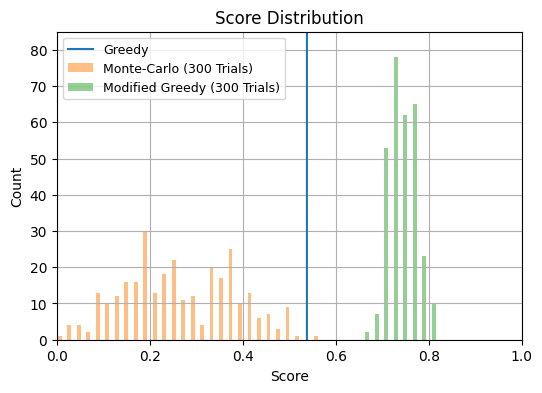

In [ ]:
sc_mc = [0.1908, 0.253, 0.132, 0.1748, 0.3506, 0.336, 0.3641, 0.3298, 0.2039,
      0.188, 0.1479, 0.1938, 0.1644, 0.3837, 0.2422, 0.3319, 0.0544, 0.3781,
      0.1612, 0.3249, 0.2584, 0.0093, 0.3369, 0.3761, 0.2282, 0.2949, 0.3447,
      0.0397, 0.1984, 0.0805, 0.155, 0.329, 0.3334, 0.1575, 0.3409, 0.2325,
      0.2986, 0.383, 0.4372, 0.5233, 0.1597, 0.4588, 0.417, 0.3435, 0.2128,
      0.244, 0.3074, 0.2931, 0.1903, 0.4711, 0.3834, 0.1776, 0.3034, 0.4982,
      0.1357, 0.116, 0.1597, 0.3711, 0.1919, 0.2504, 0.3995, 0.3627, 0.3013,
      0.4959, 0.4198, 0.2971, 0.4026, 0.2525, 0.2643, 0.2331, 0.1949, 0.4421,
      0.208, 0.2339, 0.1925, 0.0918, 0.101, 0.3962, 0.1773, 0.45, 0.368, 0.1748,
      0.3622, 0.3662, 0.2579, 0.1671, 0.2699, 0.2221, 0.2017, 0.1564, 0.2301,
      0.4788, 0.4083, 0.2176, 0.5036, 0.3824, 0.336, 0.1731, 0.2183, 0.3601,
      0.1236, 0.1022, 0.1211, 0.1977, 0.1718, 0.2789, 0.1189, 0.1309, 0.2584,
      0.3921, 0.2146, 0.1902, 0.2347, 0.42, 0.1818, 0.3471, 0.2227, 0.235,
      0.3458, 0.3268, 0.2435, 0.4948, 0.4675, 0.4363, 0.4446, 0.4625, 0.2565,
      0.3015, 0.188, 0.0296, 0.3393, 0.1886, 0.3284, 0.3727, 0.0854, 0.2369,
      0.4527, 0.2051, 0.3679, 0.3417, 0.5095, 0.2422, 0.5077, 0.2465, 0.4245,
      0.175, 0.0506, 0.2442, 0.3823, 0.3642, 0.1208, 0.2146, 0.2589, 0.1976,
      0.2408, 0.2566, 0.099, 0.1783, 0.2842, 0.0871, 0.1876, 0.1278, 0.1577,
      0.3523, 0.0903, 0.1152, 0.2942, 0.2031, 0.4413, 0.2542, 0.3493, 0.4107,
      0.4178, 0.0589, 0.2841, 0.2611, 0.3882, 0.3493, 0.3688, 0.155, 0.3953,
      0.1845, 0.1934, 0.3465, 0.3525, 0.4975, 0.1369, 0.2505, 0.3879, 0.3674,
      0.2286, 0.1974, 0.2457, 0.3369, 0.1264, 0.2898, 0.1492, 0.1881, 0.0893,
      0.4617, 0.0924, 0.3286, 0.378, 0.2641, 0.3234, 0.2913, 0.1881, 0.094,
      0.1557, 0.4093, 0.4758, 0.0873, 0.2538, 0.4106, 0.2009, 0.1932, 0.3738,
      0.0615, 0.57, 0.3516, 0.0948, 0.1323, 0.2235, 0.1732, 0.3594, 0.4222,
      0.2109, 0.1685, 0.3725, 0.2506, 0.0332, 0.4612, 0.1892, 0.098, 0.1519,
      0.366, 0.269, 0.3561, 0.2989, 0.1725, 0.0354, 0.1828, 0.1779, 0.1321,
      0.216, 0.2833, 0.1198, 0.5066, 0.3848, 0.4324, 0.114, 0.1489, 0.2855,
      0.0993, 0.2664, 0.3788, 0.3893, 0.4263, 0.3858, 0.4141, 0.3996, 0.2246,
      0.2801, 0.2331, 0.3719, 0.0492, 0.2514, 0.1962, 0.1115, 0.2817, 0.2174,
      0.3362, 0.1225, 0.4075, 0.2013, 0.1564, 0.2477, 0.1398, 0.1236, 0.3698,
      0.4254, 0.3755, 0.2594, 0.3173, 0.3854, 0.1839, 0.4981, 0.383, 0.3056,
      0.1538, 0.1899, 0.1522, 0.2436, 0.2567, 0.3741, 0.1935, 0.3302, 0.3653,
      0.1162, 0.2707]
sc_our = [0.59073, 0.74617, 0.70112, 0.66338, 0.73661, 0.699, 0.76793, 0.70058,
          0.70008, 0.66609, 0.76261, 0.69687, 0.7896, 0.69098, 0.77217, 0.70741,
          0.72285, 0.73548, 0.77005, 0.75844]
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
greedy = [-1 for n in range(5377)] + [200 for n in range(10000 - 5377)]
plt.plot(np.linspace(0, 1, len(greedy)), greedy, label="Greedy")
plt.hist([sc_mc, our_solution_score_lst], alpha=0.5, label=['Monte-Carlo (300 Trials)', 'Modified Greedy (300 Trials)'], bins=np.linspace(0, 1, 50))
# plt.hist(sc_our, alpha=0.5, label='y')
plt.legend(loc='upper left', fontsize=9)
plt.title("Score Distribution")
plt.xlim(0, 1)
plt.ylim(0, 85)
plt.xlabel("Score")
plt.ylabel("Count")
plt.grid()
plt.show()

In [ ]:
len(our_solution_score_lst[0.3])

100

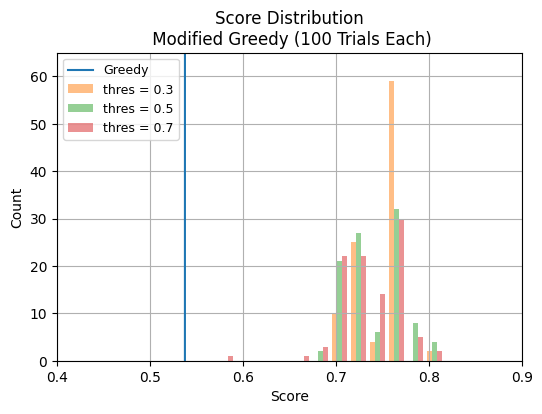

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
greedy = [-1 for n in range(5377)] + [200 for n in range(10000 - 5377)]
plt.plot(np.linspace(0, 1, len(greedy)), greedy, label="Greedy")
plt.hist([our_solution_score_lst[0.3], our_solution_score_lst[0.5], our_solution_score_lst[0.7]], alpha=0.5, label=['thres = 0.3', 'thres = 0.5', 'thres = 0.7'], bins=np.linspace(0, 1, 50))
plt.legend(loc='upper left', fontsize=9)
plt.title("Score Distribution\n Modified Greedy (100 Trials Each)")
plt.xlim(0.4, 0.9)
plt.ylim(0, 65)
plt.xlabel("Score")
plt.ylabel("Count")
plt.grid()
plt.show()

# Gene Location Visualization

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

def visualize_gene_fragments(A, B, S, d, a_count = None):
    coverage_A = coverage(S, randomseqA, d)
    coverage_B = coverage(S, randomseqB, d)
    positions_matrix = []
    for kmer in tqdm(S):
        if a_count is not None:
            for seq_idx in a_count.get(kmer, set()):
                for i in range(len(A[seq_idx]) - len(kmer) + 1):
                    s = A[seq_idx][i:i + len(kmer)]
                    if hamming_distance(s, kmer) <= d:
                        positions_matrix.append([seq_idx, i, len(kmer), kmer])
        else:
            for seq_idx in range(len(A)):
                for i in range(len(A[seq_idx]) - len(kmer) + 1):
                      s = A[seq_idx][i:i + len(kmer)]
                      if hamming_distance(s, kmer) <= d:
                          positions_matrix.append([seq_idx, i, len(kmer), kmer])

    plt.figure(figsize=(8, 4))
    unique_kmers = list(S)  # 获取所有不同的 k-mer
    unique_kmers.sort()  # 按 k-mer 进行排序
    color_palette = sns.color_palette("Spectral", len(unique_kmers))  # 使用渐变色，保证相似的 k-mer 颜色接近
    color_map = {kmer: color_palette[i] for i, kmer in enumerate(unique_kmers)}
    plt.subplot(1, 2, 1)
    for seq_idx in range(len(A)):
        plt.plot([0, len(A[seq_idx])], [seq_idx, seq_idx], color=[0.9, 0.9, 0.9], linewidth=2, label="")

    for i in range(len(positions_matrix)):
        seq_idx, start_pos, length, kmer = positions_matrix[i]
        seq_idx = int(seq_idx)
        start_pos = int(start_pos)
        length = int(length)
        plt.plot([start_pos, start_pos + length], [seq_idx, seq_idx], color=color_map[kmer], linewidth=2, label=kmer if kmer not in plt.gca().get_legend_handles_labels()[1] else "")

    plt.xlabel("Gene Position")
    plt.ylabel("Gene Sequence Index")
    plt.title("K-mer Matches (k=15-18) \nin Set A (Coverage=" + str(coverage_A) + ")")
    plt.grid(True, linestyle='--', alpha=0.5)

    #######################

    positions_matrix = []
    for kmer in tqdm(S):
        if a_count is not None:
            for seq_idx in a_count.get(kmer, set()):
                for i in range(len(B[seq_idx]) - len(kmer) + 1):
                    s = B[seq_idx][i:i + len(kmer)]
                    if hamming_distance(s, kmer) <= d:
                        positions_matrix.append([seq_idx, i, len(kmer), kmer])
        else:
            for seq_idx in range(len(B)):
                for i in range(len(B[seq_idx]) - len(kmer) + 1):
                      s = B[seq_idx][i:i + len(kmer)]
                      if hamming_distance(s, kmer) <= d:
                          positions_matrix.append([seq_idx, i, len(kmer), kmer])

    unique_kmers = list(S)  # 获取所有不同的 k-mer
    unique_kmers.sort()  # 按 k-mer 进行排序
    color_palette = sns.color_palette("Spectral", len(unique_kmers))  # 使用渐变色，保证相似的 k-mer 颜色接近
    color_map = {kmer: color_palette[i] for i, kmer in enumerate(unique_kmers)}
    plt.subplot(1, 2, 2)
    for seq_idx in range(len(A)):
        plt.plot([0, len(B[seq_idx])], [seq_idx, seq_idx], color=[0.9, 0.9, 0.9], linewidth=2, label="")

    for i in range(len(positions_matrix)):
        seq_idx, start_pos, length, kmer = positions_matrix[i]
        seq_idx = int(seq_idx)
        start_pos = int(start_pos)
        length = int(length)
        plt.plot([start_pos, start_pos + length], [seq_idx, seq_idx], color=color_map[kmer], linewidth=2, label=kmer if kmer not in plt.gca().get_legend_handles_labels()[1] else "")

    plt.xlabel("Gene Position")
    plt.ylabel("Gene Sequence Index")
    plt.title("K-mer Matches (k=15-18) \nin Set B (Coverage=" + str(coverage_B) + ")")
    plt.grid(True, linestyle='--', alpha=0.5)



    # 添加图例，显示 k-mer 对应的颜色
    plt.subplot(1, 2, 2)
    handles = [plt.Line2D([0], [0], color=color_map[kmer], linewidth=4, label=kmer) for kmer in unique_kmers]
    plt.legend(handles=handles, title="K-mer Legend", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

    plt.subplots_adjust(wspace=0.3)
    plt.show()

100%|██████████| 10/10 [00:03<00:00,  3.31it/s]


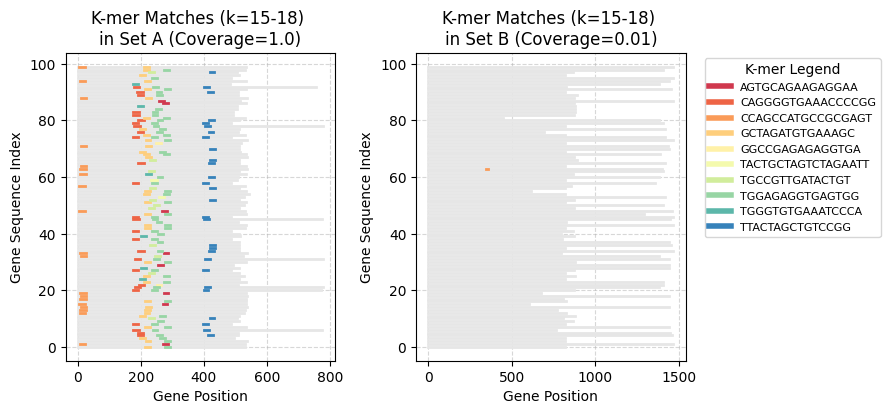

In [ ]:
best_S_5_8 = ["TGTCTCTA", "CAGACTGA", "TCCTCCCA", "GTTACCCA", "GCTTCTTA", "GGTCGCTT", "GGCGATTC", "GTGTGACC", "CGCTGTCC"]
best_S_9_14 = ['ATACTCCAG', 'CATCCTGAT', 'CGAGTAGGCGGAC', 'CGTAGGTCGC', 'GAGTCTTGAA', 'GGAGAGGCGAG', 'TAGCGACGC', 'TGACGTTACCCA']
best_S_15_18 = ['AGTGCAGAAGAGGAA', 'CAGGGGTGAAACCCCGG', 'CCAGCCATGCCGCGAGT', 'GCTAGATGTGAAAGC', 'GGCCGAGAGAGGTGA', 'TACTGCTAGTCTAGAATT', 'TGCCGTTGATACTGT', 'TGGAGAGGTGAGTGG', 'TGGGTGTGAAATCCCA', 'TTACTAGCTGTCCGG']

# visualize_gene_fragments(randomseqA, randomseqB, best_S_5_8, d)
# visualize_gene_fragments(randomseqA, randomseqB, best_S_9_14, d)
visualize_gene_fragments(randomseqA, randomseqB, best_S_15_18, d)

100%|██████████| 9/9 [00:00<00:00, 22.37it/s]


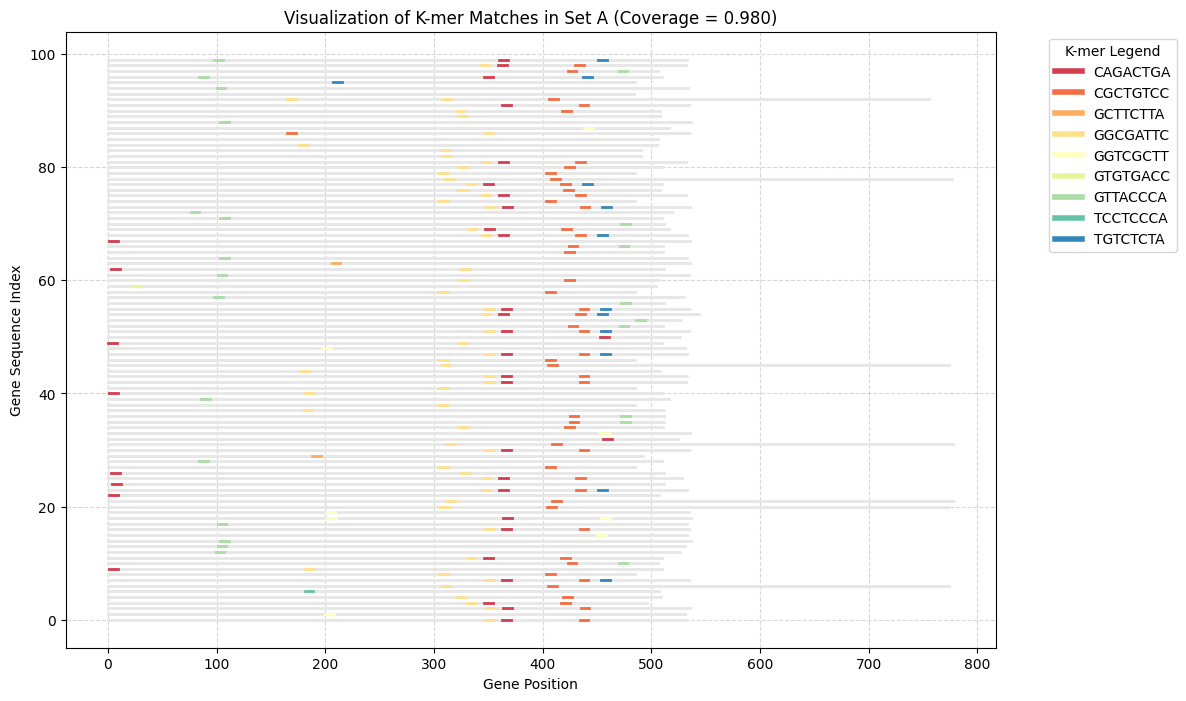

In [ ]:
visualize_gene_fragments(A, a_count, best_S, "Visualization of K-mer Matches in Set A (Coverage = 0.980)")

100%|██████████| 9/9 [00:00<00:00, 155.45it/s]


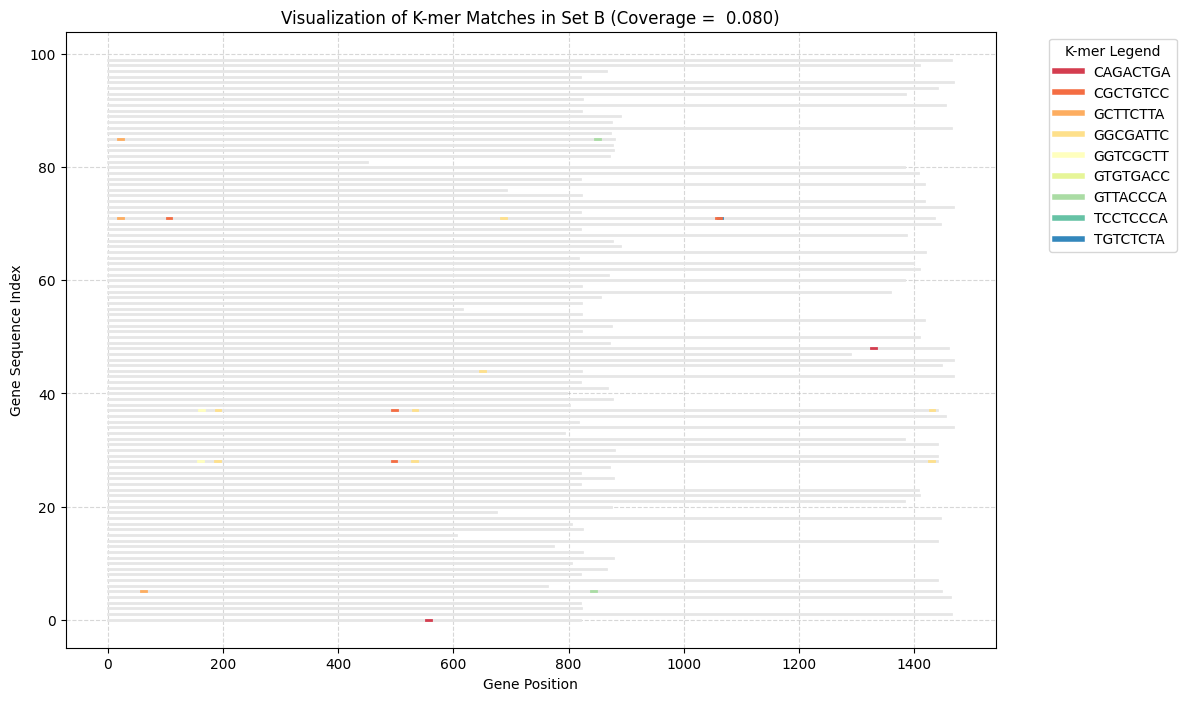

In [ ]:
visualize_gene_fragments(B, b_count, best_S, "Visualization of K-mer Matches in Set B (Coverage =  0.080)")

In [ ]:
coverage(best_S, A, d), coverage(best_S, B, d)

(0.98, 0.08)

In [ ]:
best_S_5_8 = ["TGTCTCTA", "CAGACTGA", "TCCTCCCA", "GTTACCCA", "GCTTCTTA", "GGTCGCTT", "GGCGATTC", "GTGTGACC", "CGCTGTCC"]
best_S_9_14 = ['ATACTCCAG', 'CATCCTGAT', 'CGAGTAGGCGGAC', 'CGTAGGTCGC', 'GAGTCTTGAA', 'GGAGAGGCGAG', 'TAGCGACGC', 'TGACGTTACCCA']
best_S_11_15 = ['AGTGCAGAAGAGGAA', 'CAGGGGTGAAACCCCGG', 'CCAGCCATGCCGCGAGT', 'GCTAGATGTGAAAGC', 'GGCCGAGAGAGGTGA', 'TACTGCTAGTCTAGAATT', 'TGCCGTTGATACTGT', 'TGGAGAGGTGAGTGG', 'TGGGTGTGAAATCCCA', 'TTACTAGCTGTCCGG']
print(len(best_S_11_15))

10


1872

100%|██████████| 9/9 [00:02<00:00,  4.14it/s]


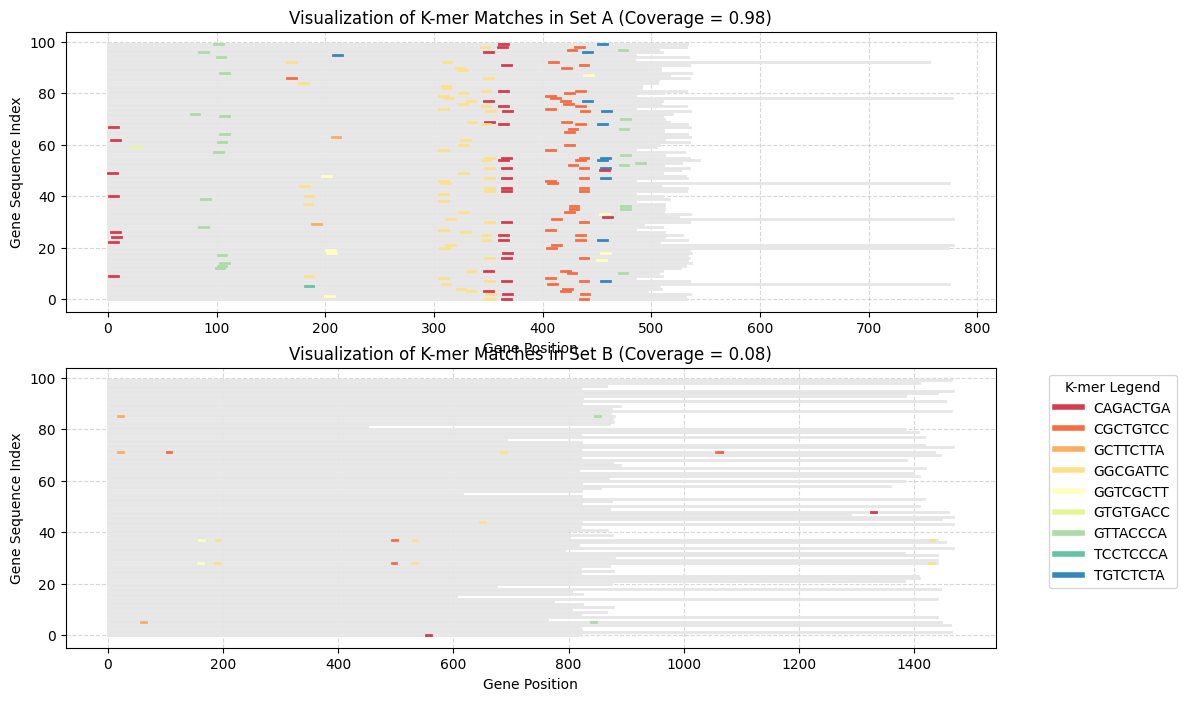

In [ ]:
best_S = best_S_5_8
d = 1
# a_count = load_count_from_csv('drive/MyDrive/BENG 202 Project/gb_data/random_a_count_5_8.csv')
coverage_A = coverage(best_S, randomseqA, d)
coverage_B = coverage(best_S, randomseqB, d)
visualize_gene_fragments(randomseqA, randomseqB, best_S_5_8, d)

# Original Code

In [ ]:
!pip install Bio
import random
import string

# Google drive mount
from google.colab import drive
drive.mount('/content/drive')

!cd 'drive/MyDrive/BENG 202 Project'
!ls 'drive/MyDrive/BENG 202 Project'

def generate_random_string(length):
    """Generate a random string of given length from ACGT."""
    return ''.join(random.choices("ACGT", k=length))

def generate_string_set(num_strings, string_length):
    """Generate a set of random strings."""
    return [generate_random_string(string_length) for _ in range(num_strings)]

def modify_set_A_with_k_mer(A, k_mer_set, ratio = 0.8):
    counts = int(len(A) * ratio)
    for k_mer in k_mer_set:
        for i in random.sample([n for n in range(len(A))], counts):
            idx = random.choice([n for n in range(len(A[i]) - len(k_mer))])
            A[i] = A[i][:idx] + k_mer + A[i][idx + k:]
    return A


def load_gb_data(A_set_filename, B_set_filename):
  from Bio import SeqIO
  A = []
  for i, record in enumerate(SeqIO.parse(A_set_filename, "genbank")):
    A.append(record.seq)
  B = []
  for i, record in enumerate(SeqIO.parse(B_set_filename, "genbank")):
    B.append(record.seq)
  return A, B

A_set_filename = 'drive/MyDrive/BENG 202 Project/gb_data/culturable_set.gb'
B_set_filename = 'drive/MyDrive/BENG 202 Project/gb_data/unculturable_set.gb'
A, B = load_gb_data(A_set_filename, B_set_filename)


# # Parameters for dataset generation
# num_strings_A = 100  # Number of strings in set A
# string_length = 50  # Length of each string

# # Generate datasets A and B
# A = generate_string_set(num_strings_A, string_length)
# B = generate_string_set(num_strings_B, string_length)

# A, B


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.9 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
'BENG 202 - Project Note (Nana).gdoc'   Group3-Round6-BrownChangWu.gdoc  'Proposal Draft.gdoc'
 dataset.ipynb			       'Potential Dataset Notes.gdoc'	  sequence.gb
 gb_data			       'Problem Formulation.gslides'	  Untitled0.ipynb


In [ ]:
from itertools import product, chain, combinations
from tqdm import tqdm

def hamming_distance(s1, s2):
    """Compute the Hamming distance between two equal-length strings."""
    return sum(c1 != c2 for c1, c2 in zip(s1, s2))

def extract_kmers(string_set, k, d):
    """Extract all unique k-mers from a set of strings."""
    kmers = []
    for s in string_set:
        for i in range(len(s) - k + 1):
            for kmers_variant in generate_variants(s[i:i + k], d):
                if kmers_variant not in kmers:
                    kmers.append(kmers_variant)
    return kmers

def d_match(kmer, string, d):
    """Check if a k-mer approximately matches any substring in a string within Hamming distance d."""
    for i in range(len(string) - len(kmer) + 1):
        if hamming_distance(kmer, string[i:i + len(kmer)]) <= d:
            return True
    return False

def coverage(S, V, d):
    """Calculate the coverage of a k-mer set S over a string set V with a given Hamming distance d."""
    match_count = sum(any(d_match(kmer, v, d) for kmer in S) for v in V)
    return match_count / len(V)

def score(A, B, S, d):
    """Calculate the score of a k-mer set S."""
    return coverage(S, A, d) - coverage(S, B, d)

# def kmer_count(S, kmers, d):
#     for
def brute_force_best_kmers(A, B, k, d, max_size=None):
    """Find the best k-mer set S that maximizes score(A, B, S, d) using brute force."""
    if max_size == None:
        max_size = len(A)

    all_kmers_A = extract_kmers(A, k, d)
    # a_count = kmer_count(A, all_kmers_A, d)
    # b_count = kmer_count(B, all_kmers_A, d)
    print(len(all_kmers_A))
    best_S = set()
    best_score = float('-inf')

    # Try every subset of k-mers from A (single k-mers for brute force approach)
    for S in tqdm(chain.from_iterable(combinations(all_kmers_A, r) for r in range(1, min(len(all_kmers_A), max_size) + 1))):
        S = list(S)
        current_score = score(A, B, S, d)
        if current_score >= best_score:
            if current_score >= 0.8:
                print(current_score, S)
            best_score = current_score
            best_S = S.copy()
        # print("checking kmer: ", kmer, "current_score: ", current_score)

    return best_S, best_score


# Parameters for dataset generation
num_strings_A = 100 # Number of strings in set A
num_strings_B = 60  # Number of strings in set B
string_length = 50  # Length of each string

# Generate datasets A and B
A = generate_string_set(num_strings_A, string_length)
B = generate_string_set(num_strings_B, string_length)
# A = ['TCTGATTACT', 'TAGATTACCT', 'CAGAACCGCC', 'AACATATTGA', 'TGACGCACGC']
# B = ['ACGGACCCGC', 'AGTTATTATC', 'ATCTTTACGC', 'CATGCAGGTA', 'GTGTGCTGAA']
# A = ['CGAACACCCCAGGTG', 'AGATGAGAGGCAATA', 'TTAGCTTTTCTGGAA', 'AATCGCCGTCTCCGG', 'TATCGGCGCGCTGAG', 'GTCGATTGGTGTAGA', 'AATTCCATCATCCCT', 'GGGTTCTACTCCTTA', 'GAAGACAAAGCCGTG', 'AGGCCAAGTTCATGC']
# B = ['ATTTTAATGCGGCCC', 'GTACGAAAAAGCGCC', 'AGTGCGCCAGCCTCT', 'CGGGGAGTTCACCTA', 'ATTAAATTAAAAGCC', 'TCACACTAGAGGAGA', 'GGCAAATAATTACGT', 'TAGTCATAATTCAGA', 'TATTCTGGCTCACTC', 'AGATGAACAAGCATA']

# num_kmer = 3
# k = 20
# true_kmers = generate_string_set(num_kmer, k)
# set_size_limit = 3

# A = modify_set_A_with_k_mer(list(A), true_kmers, ratio=0.5)

# print("Set A: ", A)
# print("Set B: ", B)
# # print("True kmer set: ", true_kmers)

# # Parameters for brute force
# d = 1  # Hamming distance threshold

# # Find the best k-mer set using brute force
# best_kmers, best_kmer_score = brute_force_best_kmers(A, B, k, d, max_size=set_size_limit)

# # Display results
# print(best_kmers, best_kmer_score)
# print(true_kmers, score(A, B, true_kmers, d))


In [ ]:
import random
import itertools

def generate_random_string(length):
    """Generate a random string of given length from ACGT."""
    return ''.join(random.choices("ACGT", k=length))

def generate_string_set(num_strings, string_length):
    """Generate a set of random strings."""
    return {generate_random_string(string_length) for _ in range(num_strings)}

def hamming_distance(s1, s2):
    """Compute the Hamming distance between two strings of equal length."""
    return sum(ch1 != ch2 for ch1, ch2 in zip(s1, s2))

def has_approximate_match(v, kmer, d):
    """
    Check if string v contains any substring of length equal to kmer
    that is within Hamming distance d of the given kmer.
    """
    k = len(kmer)
    for i in range(len(v) - k + 1):
        if hamming_distance(v[i:i+k], kmer) <= d:
            return True
    return False

def coverage(S, V, d):
    """
    Compute the fraction of strings in V that d-match the set of k-mers S.
    A string v d-matches S if it contains any substring that is within
    Hamming distance d of at least one k-mer in S.
    """
    count = 0
    for v in V:
        if any(has_approximate_match(v, kmer, d) for kmer in S):
            count += 1
    return count / len(V) if V else 0

def score(A, B, S, d):
    """
    Compute the score for a k-mer set S as:
       score(A, B, S, d) = coverage(S, A, d) - coverage(S, B, d)
    """
    return coverage(S, A, d) - coverage(S, B, d)

def brute_force_maximization_set(A, B, k, d, r):
    """
    Brute force search over all subsets (of size r) of candidate k-mers
    (extracted from set A) to find the set S that maximizes the score.

    Parameters:
      A, B : sets of strings
      k    : length of k-mers
      d    : allowed Hamming distance
      r    : fixed number of k-mers in the output set S

    Returns:
      best_S : the set of k-mers with the best score
      best_score : the best score achieved
    """
    # Extract candidate k-mers from strings in A
    candidate_kmers = set()
    for v in A:
        for i in range(len(v) - k + 1):
            candidate_kmers.add(v[i:i+k])
    candidate_kmers = list(candidate_kmers)

    best_score = -float('inf')
    best_S = None

    # Iterate over all combinations (subsets) of candidate k-mers of size r
    for subset in itertools.combinations(candidate_kmers, r):
        curr_score = score(A, B, set(subset), d)
        # print(subset, curr_score)
        if curr_score > best_score:
            best_score = curr_score
            best_S = set(subset)
    return best_S, best_score

# --- Example Usage ---

# # Parameters for dataset generation
# num_strings_A = 100  # Number of strings in set A
# num_strings_B = 100  # Number of strings in set B
# string_length = 50  # Length of each string

# # Generate datasets A and B
# A = generate_string_set(num_strings_A, string_length)
# B = generate_string_set(num_strings_B, string_length)

# # Set parameters for the problem
# k = 3   # Length of k-mers (choose small for brute force)
# d = 1   # Allowed Hamming distance (mismatches)
# r = 3   # Number of k-mers to include in the set S


for r in tqdm(range(3)):
    # Run the brute force algorithm for set selection
    best_S, best_score = brute_force_maximization_set(A, B, k, d, r + 1)
    print("Best k-mer set S:", best_S)
    print("Best score:", best_score)


  0%|          | 0/3 [00:00<?, ?it/s]

Best k-mer set S: {'TAAA'}
Best score: 0.7


 67%|██████▋   | 2/3 [00:00<00:00,  7.02it/s]

Best k-mer set S: {'GAGA', 'TAAA'}
Best score: 0.7


100%|██████████| 3/3 [00:02<00:00,  1.03it/s]

Best k-mer set S: {'GAGA', 'TAAA', 'AAAA'}
Best score: 0.6000000000000001


In [ ]:
from itertools import product
from collections import defaultdict
import random

def generate_kmers(k):
    """Generate all possible k-mers."""
    return {''.join(p) for p in product('ACGT', repeat=k)}

def count_kmers(sequences, k):
    """Extract all k-mers from sequences and count their occurrences."""
    kmers = defaultdict(int)
    for seq in sequences:
        for i in range(len(seq) - k + 1):
            kmers[seq[i:i + k]] += 1
    return kmers

def hamming_distance(s1, s2):
    """Calculate the Hamming distance between two strings."""
    return sum(c1 != c2 for c1, c2 in zip(s1, s2))

def coverage(S, V, k, d):
    """Compute the fraction of sequences in V that contain any k-mer from S within Hamming distance d."""
    count = 0
    for seq in V:
        for i in range(len(seq) - k + 1):
            km = seq[i:i + k]
            if any(hamming_distance(km, s) <= d for s in S):
                count += 1
                break
    return count / len(V)

def compute_score(A, B, S, k, d):
    """Compute the score of the characteristic k-mer set S."""
    return coverage(S, A, k, d) - coverage(S, B, k, d)

def find_characteristic_kmers(A, B, k, d, max_iters=1000):
    """Greedy approach to find a characteristic k-mer set maximizing the score."""
    all_kmers_A = count_kmers(A, k)
    all_kmers_B = count_kmers(B, k)

    candidate_kmers = set(all_kmers_A.keys()) - set(all_kmers_B.keys())
    selected_kmers = set()

    best_score = -1
    best_kmers = set()

    for _ in range(max_iters):

        kmers_to_try = random.sample(sorted(candidate_kmers), min(len(candidate_kmers), 20))
        for km in kmers_to_try:
            temp_set = selected_kmers | {km}
            score = compute_score(A, B, temp_set, k, d)
            if score > best_score:
                best_score = score
                best_kmers = temp_set.copy()
        selected_kmers = best_kmers
        print("iteration: " , best_score, best_kmers)
    return selected_kmers

In [ ]:
# greedy - make a.count smaller, need b.count? Alter thresholds in some way
# d always 1, k for genome might vary

from collections import defaultdict

def generate_variants(kmer, d):
    variants = set()
    n = len(kmer)

    def helper(current, pos, changes_made):
        if pos == n:
            variants.add(current)
            return
        # Keep the current character
        helper(current + kmer[pos], pos + 1, changes_made)
        # Change to another character if we can still make changes
        if changes_made < d:
            for c in ['A', 'C', 'G', 'T']:
                if c != kmer[pos]:
                    helper(current + c, pos + 1, changes_made + 1)

    helper('', 0, 0)
    return variants

def find_characteristic_kmer_set(A, B, mk, K, d):  # Is this the greedy one?
    a_count = defaultdict(set)  # Maps k-mer to set of indices in A it covers
    b_count = defaultdict(set)  # Maps k-mer to set of indices in B it covers

    # Process each genome in A to populate a_count
    for idx, genome in enumerate(A):
        for k in range(mk, K + 1):
            for i in range(len(genome) - k + 1):
                kmer = genome[i:i+k]
                variants = generate_variants(kmer, d)
                for s in variants:
                    a_count[s].add(idx)

    # Process each genome in B to populate b_count
    for idx, genome in enumerate(B):
        for k in range(mk, K + 1):
            for i in range(len(genome) - k + 1):
                kmer = genome[i:i+k]
                variants = generate_variants(kmer, d)
                for s in variants:
                    b_count[s].add(idx)

    # Collect all candidate k-mers that can cover at least one A genome
    candidate_kmers = list(a_count.keys())

    # print(a_count, b_count)
    # for key in a_count:
    #   print(key, a_count[key])

    covered_A = set()
    covered_B = set()
    selected_S = set()

    while True:
        max_gain = -float('inf')
        best_kmer = None
        for s in candidate_kmers:
            if s in selected_S:
                continue
            # Calculate new coverage for A and B
            a_new = len(a_count[s] - covered_A) / len(A)
            b_new = len(b_count.get(s, set()) - covered_B) / len(B)
            current_gain = a_new - b_new
            if current_gain > max_gain:
                max_gain = current_gain
                best_kmer = s
        # If no positive gain, stop
        if max_gain <= 0:
            break
        # Update covered sets and selected k-mers
        selected_S.add(best_kmer)
        covered_A.update(a_count[best_kmer])
        covered_B.update(b_count.get(best_kmer, set()))
        print(selected_S)

  return selected_S, a_count, b_count

  S, a_count, b_count = find_characteristic_kmer_set(A, B, 7, 8, 1)


{'CGGATGC'}
{'CGGATGC', 'GGATTCC'}
{'CGGATGC', 'GGATTCC', 'TCTGCAC'}
{'TTTGATG', 'CGGATGC', 'GGATTCC', 'TCTGCAC'}
{'GAGGGGA', 'CGGATGC', 'GGATTCC', 'TCTGCAC', 'TTTGATG'}
{'GAGGGGA', 'CGGATGC', 'GGATTCC', 'TCTGCAC', 'TTTGATG', 'ACATTCG'}
{'GAGGGGA', 'CGGATGC', 'CTTAAGG', 'GGATTCC', 'TCTGCAC', 'TTTGATG', 'ACATTCG'}
{'GAGGGGA', 'CGGATGC', 'CTTAAGG', 'GGATTCC', 'TCTGCAC', 'TTTGATG', 'ACATTCG', 'CTGTTAT'}
{'GAGGGGA', 'CGGATGC', 'CTTAAGG', 'GAAACGA', 'GGATTCC', 'TCTGCAC', 'TTTGATG', 'ACATTCG', 'CTGTTAT'}
{'GAGGGGA', 'CGGATGC', 'CTTAAGG', 'GAAACGA', 'GGATTCC', 'GCATATA', 'TCTGCAC', 'TTTGATG', 'ACATTCG', 'CTGTTAT'}
{'GAGGGGA', 'CGGATGC', 'CTTAAGG', 'GAAACGA', 'CTCGTGC', 'GGATTCC', 'GCATATA', 'TCTGCAC', 'TTTGATG', 'ACATTCG', 'CTGTTAT'}
{'GAGGGGA', 'CGGATGC', 'TCCTAGGT', 'CTTAAGG', 'GAAACGA', 'CTCGTGC', 'GGATTCC', 'GCATATA', 'TCTGCAC', 'TTTGATG', 'ACATTCG', 'CTGTTAT'}
{'GAGGGGA', 'CGGATGC', 'TCCTAGGT', 'CTTAAGG', 'GAAACGA', 'CTCGTGC', 'GGATTCC', 'GCATATA', 'TCTGCAC', 'TGTGAAC', 'TTTGATG', 'ACATT

In [ ]:
score(A, B, S, 1)

0.9333333333333333

In [ ]:
S, len(S)

({'ACATTCG',
  'ATATGCTT',
  'CGGATGC',
  'CTCGTGC',
  'CTGTTAT',
  'CTTAAGG',
  'GAAACGA',
  'GAGGGGA',
  'GCATATA',
  'GGATTCC',
  'TCCTAGGT',
  'TCTGCAC',
  'TGTGAAC',
  'TTTGATG'},
 14)

In [ ]:
cnt = 0
for key in result:
  if len(result[key]) > 2:
    cnt += 1
    # print(key)
print(cnt)



339


In [ ]:
# Monte carlo - run longer with improved thresholds for stop (negative cnt)

from collections import defaultdict

def generate_variants(kmer, d):
    variants = set()
    n = len(kmer)

    def helper(current, pos, changes_made):
        if pos == n:
            variants.add(current)
            return
        # Keep the current character
        helper(current + kmer[pos], pos + 1, changes_made)
        # Change to another character if we can still make changes
        if changes_made < d:
            for c in ['A', 'C', 'G', 'T']:
                if c != kmer[pos]:
                    helper(current + c, pos + 1, changes_made + 1)

    helper('', 0, 0)
    return variants

def find_characteristic_kmer_set(A, B, mk, K, d):  # Is this the greedy one?
    a_count = defaultdict(set)  # Maps k-mer to set of indices in A it covers
    b_count = defaultdict(set)  # Maps k-mer to set of indices in B it covers

    # Process each genome in A to populate a_count
    for idx, genome in enumerate(A):
        for k in range(mk, K + 1):
            for i in range(len(genome) - k + 1):
                kmer = genome[i:i+k]
                variants = generate_variants(kmer, d)
                for s in variants:
                    a_count[s].add(idx)

    # Process each genome in B to populate b_count
    for idx, genome in enumerate(B):
        for k in range(mk, K + 1):
            for i in range(len(genome) - k + 1):
                kmer = genome[i:i+k]
                variants = generate_variants(kmer, d)
                for s in variants:
                    b_count[s].add(idx)

    # Collect all candidate k-mers that can cover at least one A genome
    candidate_kmers = list(a_count.keys())

    # print(a_count, b_count)
    # for key in a_count:
    #   print(key, a_count[key])

    covered_A = set()
    covered_B = set()
    selected_S = set()
    negative_cnt = 0
    while True:
        max_gain = -float('inf')
        best_kmer = None
        s = random.sample(sorted(a_count), 1)[0]

        if s not in selected_S:
            # Calculate new coverage for A and B
            a_new = len(a_count[s] - covered_A) / len(A)
            b_new = len(b_count.get(s, set()) - covered_B) / len(B)
            current_gain = a_new - b_new
            if current_gain > max_gain:
                max_gain = current_gain
                best_kmer = s
        # If no positive gain, stop
        if max_gain <= 0:
            negative_cnt += 1
            if negative_cnt == 10:
                break
        else:
          negative_cnt = 0

          # Update covered sets and selected k-mers
          selected_S.add(best_kmer)
          covered_A.update(a_count[best_kmer])
          covered_B.update(b_count.get(best_kmer, set()))
          # print(selected_S)

    return selected_S, a_count, b_count

S, a_count, b_count = find_characteristic_kmer_set(A, B, 5, 12, 1)

best_score = score(A, B, S, 1)
best_set = S

for _ in tqdm(range(10)):

  S, a_count, b_count = find_characteristic_kmer_set(A, B, 5, 12, 1)
  print(sorted(S))
  curr_score = score(A, B, S, 1)
  if curr_score > best_score:
    best_score = curr_score
    best_set = S
len(best_set), best_score

  0%|          | 0/10 [00:00<?, ?it/s]

['AAAAGTG', 'AAACTCCCAGA', 'AACTCCGA', 'AAGCCAGCC', 'ACGCGAGGATT', 'ACGGCCTCAATG', 'ACGGCCTGA', 'ACGTACTTG', 'ACTCCACTCGG', 'AGCAAAGTGCA', 'AGCATTCAAACT', 'AGCGAAAGGAC', 'AGCTGACTTGCG', 'AGTTAGGATATA', 'ATCAAGATCTAC', 'CAAGGTCAAA', 'CACGCAGAA', 'CATCGGCGGG', 'CCGGTTCTTCCA', 'CCTGACCGCAGA', 'CCTGGATGCAC', 'CGGCCGAGGAAG', 'CGTCGTCACTAG', 'CTAGCTACAC', 'CTGGCTAACCCT', 'CTTACTCCA', 'CTTAGTAGCA', 'GAAGATTCAGT', 'GAATAAAGATA', 'GACGGGCTTG', 'GAGGTACAGTTC', 'GAGTTGACTAA', 'GCATGCAGTACA', 'GCCCAGGGAAC', 'GCGCATAGC', 'GCGGCTCGTT', 'GCGTGAAG', 'GCTGGGTGACCT', 'GCTTGGAG', 'GGGTGCCGATT', 'GGTTGTCTCGCT', 'GTAGGGTGCA', 'GTCATCCTTC', 'GTGAGCAGCGAT', 'GTGCATAA', 'TAAGCGGAACAG', 'TAATTGAA', 'TACGACAACC', 'TACTGTGGGGCT', 'TATCAGGCAGTA', 'TATTTCTGGTG', 'TGACTCAAA', 'TGCAACCAAA', 'TGCACCCCTGCG', 'TGCGGTAGTT', 'TGGCGGTTT', 'TGGGTCAGTG', 'TTAGGGGCACCC', 'TTAGTGCTG', 'TTCACGTACAC', 'TTCAGTTACG', 'TTGAATTGGCT', 'TTGCTAAGCA', 'TTGTCAGCAT', 'TTTCAGCAAGC']


 10%|█         | 1/10 [00:45<06:45, 45.00s/it]

['AATCGAGAAG', 'ACAGCTTCTG', 'ACAGTCTCA', 'ACATTGCCGCTT', 'ACCATCCTAC', 'ACGAAGTAC', 'ACTCGGCCA', 'AGCCGAGGCGA', 'AGGGTGTTTGCA', 'AGGTCAGGTC', 'AGTAACAGTAC', 'AGTTTGCCATTT', 'ATATAATGCTG', 'ATGCAAACACTT', 'ATGCTTATGCA', 'ATTATAGGTGA', 'CAACGAGTCAG', 'CACGTGTGGA', 'CCTGAACTCCG', 'CGGGGATAGTTT', 'CTAATCAACA', 'CTCATGCAAA', 'CTCCATTCA', 'CTCTTTCCATCG', 'GAACTGGAGT', 'GACGTGGCA', 'GACTGGAGACTC', 'GAGATGACGAA', 'GATCTTCAAGT', 'GCCGGACCCG', 'GCTATGAGGGGC', 'GCTCGGGCCG', 'GGACGCAATT', 'GGATTGCCTATG', 'GGCATCCTCTC', 'GGTCCCACTTCA', 'GGTGATCTCA', 'GGTGGAGCCA', 'GGTTCAATTAA', 'GTACTAGGC', 'GTCAGGGGGAG', 'GTTACTGC', 'GTTCCACAT', 'TAGGATAGAG', 'TAGTCCTCG', 'TATGCGGACCTG', 'TCGCTTAGAATA', 'TGCTGTAT', 'TGGAGAGGACGC', 'TTAGACGTTT', 'TTGCACACTCCG', 'TTGGCTAGCTAG']


 20%|██        | 2/10 [01:17<05:01, 37.68s/it]

...

['AACTAAGGGGT', 'AACTTCGGTCA', 'AAGTAAAACCG', 'AAGTTTCGGTGG', 'ACGAGCGTTTCA', 'ACTGGTCGT', 'ACTGTGGACTA', 'AGATAGATGT', 'AGTGGGCGACT', 'AGTTCGTTACA', 'ATCGATCCACAT', 'ATTACGAGGTA', 'CAGCCTGCTAAG', 'CAGTCAGGCG', 'CATGAAAATG', 'CCCCACAGATTT', 'CCTAAGATCCTT', 'CCTCAACCG', 'CGGCGTGATTAT', 'CGGGCGAGCA', 'CGGTGTACATTG', 'CGTACATGGA', 'CGTGACAC', 'CGTGAGCGGT', 'CGTTTGTGAAA', 'CTCATCATTAG', 'CTCGGAGGA', 'CTCTGCGCAAAG', 'CTTACAGACC', 'GAACTGAAGTTC', 'GCGGAAC', 'GGCAACATCGT', 'GGGAACTGCC', 'GGGACACGTGCA', 'GGGCAAACCA', 'GGTGTTGCCAT', 'GTGGGACTGACC', 'GTTGAGGG', 'GTTGATGTGGA', 'TAGCATAGCAC', 'TATACGCCGA', 'TATTCTTTGTG', 'TCAACTCGC', 'TCAGCCCAACG', 'TCCATCATCCG', 'TCTTTCACGCT', 'TGCGTTCTC', 'TGGGAATA', 'TGGTTACCGGA', 'TGTTTTATTAC', 'TTAAGGTAG', 'TTCCGGCTGGG']


 90%|█████████ | 9/10 [06:49<00:47, 47.04s/it]

['AAACCCTGGAT', 'AAAGCGTCATTG', 'AAGGTCGTAAT', 'AATCGAGATGA', 'AATCGCGAA', 'AATGGTTTAG', 'ACATTTATGAA', 'ACGGTTATTCA', 'ACTGAACTTC', 'ACTTTCAACC', 'AGATTACCTG', 'AGTGCTCCAA', 'AGTGGATGGTC', 'AGTTAGCTATGC', 'ATATGGCTAGT', 'ATCCAACGTTA', 'ATCCCATCT', 'ATGATTCGAT', 'ATTGACGAATT', 'ATTTCTCCTGA', 'CACGGTTAGCTA', 'CACTGCTCGGG', 'CAGCCTGCTG', 'CAGTACGCATT', 'CATGATTCAC', 'CCAGGTGCA', 'CCATCGTGAGCC', 'CCTACGAA', 'CGCAGAGATCGC', 'CGCCTAACGT', 'CTAGAACTCG', 'GAAAACCG', 'GAAGTGGAAAG', 'GAGAGTGTAGGC', 'GAGTAAATTATG', 'GCATCGTGAAC', 'GCCCTTCC', 'GCCTTGGAGGTC', 'GCGAACCCCTT', 'GCGCCCAGTA', 'GCGGTCGTCAA', 'GCGTTGGAAGCG', 'GCTAGAACCGCT', 'GCTAGTGTA', 'GCTGAGTCTC', 'GCTGGTCTTT', 'GGAGCTGCCCG', 'GGATCACAC', 'GGCATCATTTCT', 'GGCCCGCGGATG', 'GGCCCTAACTAG', 'GGGGTCCTGG', 'GGTCTGAACG', 'GTAGGTTCTCCC', 'GTCCAAGGCGT', 'GTGCGTATCAT', 'GTGGACCCAC', 'GTTATCCTAT', 'TACACTGGCGCT', 'TACTACCG', 'TAGCCAACG', 'TAGCTCGCTGT', 'TATAAGAGTGTG', 'TATAAGTTATT', 'TCGCGCGT', 'TCTCAACCCAG', 'TGCCCCTAAAC', 'TGGCATTCTAA', 'TGTCAC

100%|██████████| 10/10 [07:43<00:00, 46.33s/it]


(81, 0.8433333333333334)

In [ ]:
best_set, len(best_set)

({'AAGCAAAT',
  'AAGCATTAA',
  'AAGGAAAACG',
  'AAGTGGAAAG',
  'ACCGTTTTGCAA',
  'ACGGACTAAGTA',
  'ACGGTCTGGCT',
  'ACTAATCCGAAC',
  'ACTCAAATGGCT',
  'ACTTGTATAAT',
  'AGAACGTCGT',
  'AGCCCGTGATA',
  'AGGTTACAAGG',
  'AGTATTATC',
  'AGTGAGCTAG',
  'AGTTGTTA',
  'ATACTATTAC',
  'ATATACCAG',
  'ATGGACATATT',
  'CAAGTCCAGT',
  'CAATCAAAT',
  'CAGCGGGTAATA',
  'CAGGAAAAAA',
  'CAGGCCCAGA',
  'CCAGGGGCTTTG',
  'CCGACAGTGTC',
  'CCGGATTGATT',
  'CCGTCGTCAATT',
  'CCTACTTCATT',
  'CCTCAGTGGGTG',
  'CCTGGTAC',
  'CGAAACGACAG',
  'CGACATGATG',
  'CGGTGAAAACCT',
  'CGTGGATG',
  'CGTTGTCCC',
  'CTAAGAGCTCT',
  'CTCGTTGGTCT',
  'CTTGCTTACCGT',
  'GAAGATAGG',
  'GAGCACAAGGC',
  'GAGTCCTTGATG',
  'GAGTTGGGAG',
  'GATATGACATGG',
  'GATCGACAACCT',
  'GATCTGCACCT',
  'GCACTTACC',
  'GCAGTGGGAT',
  'GCATCCCCCGGT',
  'GCATTTATCTT',
  'GCGAGGCCGAA',
  'GCGATCAT',
  'GGAAGGCTCA',
  'GGAGAAGCCT',
  'GGATAAAA',
  'GGGGGGGCTGC',
  'GGGTTACAT',
  'GGTAAATG',
  'GGTGGCAACCA',
  'GTCCGGAC',
  'GTCGGATGCGG',
  

In [ ]:
# Jay

from collections import defaultdict

def generate_variants(kmer, d):
    variants = set()
    n = len(kmer)

    def helper(current, pos, changes_made):
        if pos == n:
            variants.add(current)
            return
        # Keep the current character
        helper(current + kmer[pos], pos + 1, changes_made)
        # Change to another character if we can still make changes
        if changes_made < d:
            for c in ['A', 'C', 'G', 'T']:
                if c != kmer[pos]:
                    helper(current + c, pos + 1, changes_made + 1)

    helper('', 0, 0)
    return variants

def find_characteristic_kmer_set(A, B, mk, K, d):  # Is this the greedy one?
    a_count = defaultdict(set)  # Maps k-mer to set of indices in A it covers
    b_count = defaultdict(set)  # Maps k-mer to set of indices in B it covers

    # Process each genome in A to populate a_count
    for idx, genome in enumerate(A):
        for k in range(mk, K + 1):
            for i in range(len(genome) - k + 1):
                kmer = genome[i:i+k]
                variants = generate_variants(kmer, d)
                for s in variants:
                    a_count[s].add(idx)

    # Process each genome in B to populate b_count
    for idx, genome in enumerate(B):
        for k in range(mk, K + 1):
            for i in range(len(genome) - k + 1):
                kmer = genome[i:i+k]
                variants = generate_variants(kmer, d)
                for s in variants:
                    b_count[s].add(idx)

    # Collect all candidate k-mers that can cover at least one A genome
    candidate_kmers = list(a_count.keys())

    # print(a_count, b_count)
    # for key in a_count:
    #   print(key, a_count[key])

    covered_A = set()
    covered_B = set()
    selected_S = set()
    negative_cnt = 0
    while True:
        max_gain = -float('inf')
        best_kmer = None
        s = random.sample(sorted(a_count), 1)[0]

        if s not in selected_S:
            # Calculate new coverage for A and B
            a_new = len(a_count[s] - covered_A) / len(A)
            b_new = len(b_count.get(s, set()) - covered_B) / len(B)
            current_gain = a_new - b_new
            if current_gain > max_gain:
                max_gain = current_gain
                best_kmer = s
        # If no positive gain, stop
        if max_gain <= 0:
            negative_cnt += 1
            if negative_cnt == 10:
                break
        else:
          negative_cnt = 0

          # Update covered sets and selected k-mers
          selected_S.add(best_kmer)
          covered_A.update(a_count[best_kmer])
          covered_B.update(b_count.get(best_kmer, set()))
          # print(selected_S)

    return selected_S, a_count, b_count

S, a_count, b_count = find_characteristic_kmer_set(A, B, 5, 12, 1)

best_score = score(A, B, S, 1)
best_set = S

for _ in tqdm(range(10)):

  S, a_count, b_count = find_characteristic_kmer_set(A, B, 5, 12, 1)
  print(sorted(S))
  curr_score = score(A, B, S, 1)
  if curr_score > best_score:
    best_score = curr_score
    best_set = S
len(best_set), best_score

In [ ]:
# Nana

from collections import defaultdict

def generate_variants(kmer, d):
    variants = set()
    n = len(kmer)

    def helper(current, pos, changes_made):
        if pos == n:
            variants.add(current)
            return
        # Keep the current character
        helper(current + kmer[pos], pos + 1, changes_made)
        # Change to another character if we can still make changes
        if changes_made < d:
            for c in ['A', 'C', 'G', 'T']:
                if c != kmer[pos]:
                    helper(current + c, pos + 1, changes_made + 1)

    helper('', 0, 0)
    return variants

def find_characteristic_kmer_set(A, B, mk, K, d):  # Is this the greedy one?
    a_count = defaultdict(set)  # Maps k-mer to set of indices in A it covers
    b_count = defaultdict(set)  # Maps k-mer to set of indices in B it covers

    # Process each genome in A to populate a_count
    for idx, genome in enumerate(A):
        for k in range(mk, K + 1):
            for i in range(len(genome) - k + 1):
                kmer = genome[i:i+k]
                variants = generate_variants(kmer, d)
                for s in variants:
                    a_count[s].add(idx)

    # Process each genome in B to populate b_count
    for idx, genome in enumerate(B):
        for k in range(mk, K + 1):
            for i in range(len(genome) - k + 1):
                kmer = genome[i:i+k]
                variants = generate_variants(kmer, d)
                for s in variants:
                    b_count[s].add(idx)

    # Collect all candidate k-mers that can cover at least one A genome
    candidate_kmers = list(a_count.keys())

    # print(a_count, b_count)
    # for key in a_count:
    #   print(key, a_count[key])

    covered_A = set()
    covered_B = set()
    selected_S = set()
    negative_cnt = 0
    while True:
        max_gain = -float('inf')
        best_kmer = None
        s = random.sample(sorted(a_count), 1)[0]

        if s not in selected_S:
            # Calculate new coverage for A and B
            a_new = len(a_count[s] - covered_A) / len(A)
            b_new = len(b_count.get(s, set()) - covered_B) / len(B)
            current_gain = a_new - b_new
            if current_gain > max_gain:
                max_gain = current_gain
                best_kmer = s
        # If no positive gain, stop
        if max_gain <= 0:
            negative_cnt += 1
            if negative_cnt == 10:
                break
        else:
          negative_cnt = 0

          # Update covered sets and selected k-mers
          selected_S.add(best_kmer)
          covered_A.update(a_count[best_kmer])
          covered_B.update(b_count.get(best_kmer, set()))
          # print(selected_S)

    return selected_S, a_count, b_count

S, a_count, b_count = find_characteristic_kmer_set(A, B, 5, 12, 1)

best_score = score(A, B, S, 1)
best_set = S

for _ in tqdm(range(10)):

  S, a_count, b_count = find_characteristic_kmer_set(A, B, 5, 12, 1)
  print(sorted(S))
  curr_score = score(A, B, S, 1)
  if curr_score > best_score:
    best_score = curr_score
    best_set = S
len(best_set), best_score